# **Lab 02 - Introduction to Q-learning**

##### Copyright by UIT-NC@NT549

## **Some instructions before getting started**:
<div style="font-family: 'Arial'; font-size: 16px; line-height: 1.6; text-align: justify;">

Start the Kernel: At the top right, choose <strong>Select Kernel ➞ Python Environments...</strong>

You can run all code blocks to check: From the menu bar, choose <strong>Run All</strong>.

Complete all code blocks marked with the comment <span style="font-family: monospace; font-weight: bold; color:white; background-color: green;"> ### YOU NEED TO WRITE YOUR CODE BELOW ### </span>
</div>

## Part 1: Implementing Q-learning with the FrozenLake-v1 environment

In [1]:
# import Gymnasium library and alias as gym
import gymnasium as gym
import random

In [2]:
# ============================================================
# Q-learning agent for Gymnasium FrozenLake-v1
# ------------------------------------------------------------
# This script trains an agent to learn a state-action value table
# Q(s, a) using the Q-learning algorithm and an epsilon-greedy policy.
#
# Environment:
# - FrozenLake-v1 (4x4 by default)
# - is_slippery=False -> deterministic movement (easier learning)
#
# High-level flow:
# 1) Create environment and agent
# 2) Train over many episodes
# 3) Print and export learned Q-table
# 4) Demonstrate the learned policy in text mode and pygame mode
# ============================================================


class QLearningAgent:
    # Agent stores Q-values in a dictionary keyed by (state, action).
    # If a (state, action) pair has never been seen, its Q-value is treated as 0.
    def __init__(self, env, alpha=0.1, gamma=0.9):
        self.env = env
        self.alpha = alpha  # Learning rate: how much to update old Q-values
        self.gamma = gamma  # Discount factor: importance of future rewards
        self.q_table = {}   # Sparse Q-table: {(state, action): q_value}

    def get_q_value(self, state, action):
        # Return Q(s, a). If missing, return 0.0 (default for unseen pairs).
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        return self.q_table.get((state, action), 0.0)


    def update_q_value(self, state, action, reward, next_state):
        # Q-learning update rule:
        #   Q(s,a) <- (1 - alpha)*Q(s,a) + alpha*(reward + gamma*max_a' Q(s',a'))
        #
        # 1) Estimate best possible future value at next_state
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        best_next_q = max(
            self.get_q_value(next_state, a) for a in range(self.env.action_space.n)
        )

        # 2) Current estimate for (state, action)
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        current_q = self.get_q_value(state, action)

        # 3) Temporal-difference target
        # Reward for current step + discounted best future value
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        target_q = reward + self.gamma * best_next_q

        # 4) Blend old estimate with new target
        # New Q-value is a weighted average of old and new information
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        new_q =  (1-self.alpha)*current_q + self.alpha*target_q

        # 5) Save updated Q-value
        self.q_table[(state, action)] = new_q

    def choose_action(self, state, epsilon=0.1):
        # Epsilon-greedy action selection:
        # - With probability epsilon: explore (random action)
        # - Otherwise: exploit (choose action with highest Q-value)

        # 1) Exploration: random action with probability epsilon
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        if random.random() < epsilon:
            return self.env.action_space.sample()

        # Compute Q-values for all actions in current state
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        q_values = [self.get_q_value(state, a) for a in range(self.env.action_space.n)]
        max_q = max(q_values)

        # Tie-breaking: if multiple actions share max Q, choose randomly among them
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        best_actions = [a for a, q in enumerate(q_values) if q == max_q]
        return random.choice(best_actions)

    def choose_greedy_action(self, state):
        # Pure greedy policy (epsilon=0):
        # Always choose one of the best actions by Q-value.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        q_values = [self.get_q_value(state, a) for a in range(self.env.action_space.n)]
        max_q = max(q_values)
        best_actions = [a for a, q in enumerate(q_values) if q == max_q]
        return random.choice(best_actions)


def export_q_table_to_txt(agent, file_path="q_table_final.txt"):
    """Export all learned Q-values to a CSV-like text file.

    File format:
        State,Action,Q-value
        0,0,0.000000
        ...
    """
    with open(file_path, "w", encoding="utf-8") as f:
        f.write("State,Action,Q-value\n")
        # Sort keys for stable, readable output
        for (state, action) in sorted(agent.q_table.keys()):
            q_val = agent.q_table[(state, action)]
            f.write(f"{state},{action},{q_val:.6f}\n")
    print(f"Q-table exported to: {file_path}")


def show_final_result_text(agent):
    """Run one full evaluation episode in ANSI text mode.

    - Uses a greedy policy (no exploration).
    - Prints board state after each step.
    - Useful for notebook/terminal environments.
    """
    demo_env = gym.make("FrozenLake-v1", is_slippery=False, render_mode="ansi")
    state, _ = demo_env.reset()

    print("=== FINAL RUN WITH GREEDY POLICY (TEXT) ===")
    print(demo_env.render())

    done = False
    step = 0
    reward = 0

    while not done:
        # Pick best action according to learned Q-table
        action = agent.choose_greedy_action(state)

        # Interact with environment
        next_state, reward, terminated, truncated, _ = demo_env.step(action)

        # Episode stops if goal/hole reached (terminated) or cutoff (truncated)
        done = terminated or truncated
        step += 1

        # Log progress and render current map
        print(f"Step {step} - Action: {action}, Reward: {reward}")
        print(demo_env.render())

        # Move to next state
        state = next_state

    # Final status
    print("Agent reached the goal!" if reward > 0 else "Agent failed to reach the goal.")
    demo_env.close()


def show_final_result_pygame(agent, delay_seconds=0.5):
    """
    Run one full evaluation episode with GUI rendering ("human" mode).

    Note:
    - Requires a local environment that supports opening windows.
    - In remote/notebook servers without display, this may not work.
    """
    import time

    demo_env = gym.make("FrozenLake-v1", is_slippery=False, render_mode="human")
    state, _ = demo_env.reset()

    print("=== FINAL RUN WITH GREEDY POLICY (PYGAME/HUMAN) ===")
    done = False
    step = 0
    reward = 0

    while not done:
        action = agent.choose_greedy_action(state)
        next_state, reward, terminated, truncated, _ = demo_env.step(action)
        done = terminated or truncated
        step += 1

        print(f"Step {step} - Action: {action}, Reward: {reward}")
        state = next_state

        # Slow down transitions so movement can be observed clearly
        time.sleep(delay_seconds)

    print("Agent reached the goal!" if reward > 0 else "Agent failed to reach the goal.")

    # Keep final frame visible briefly
    time.sleep(1.0)
    demo_env.close()


# ============================================================
# Training routine
# ============================================================

if __name__ == "__main__":
    # Create deterministic FrozenLake environment for training
    ### YOU NEED TO WRITE YOUR CODE BELOW ###
    # HERE
    env = gym.make("FrozenLake-v1", is_slippery=False)

    # Initialize Q-learning agent with default hyperparameters
    ### YOU NEED TO WRITE YOUR CODE BELOW ###
    # HERE
    agent = QLearningAgent(env)

    # Number of independent training episodes
    num_episodes = 1000

    # Main training loop
    for _ in range(num_episodes):
        # Reset environment at start of each episode
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        state, _ = env.reset()
        done = False

        # Roll out one episode until terminal state
        while not done:
            # Choose action with exploration
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            action = agent.choose_action(state, epsilon=0.1)

            # Execute action in environment
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # Update Q-table from transition (s, a, r, s')
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            agent.update_q_value(state, action, reward, next_state)

            # Advance to next state
            state = next_state

    # Print learned Q-table entries
    print("Training completed. Q-table:")
    for (state, action) in sorted(agent.q_table.keys()):
        q_val = agent.q_table[(state, action)]
        print(f"State: {state}, Action: {action}, Q-value: {q_val:.2f}")

    # Save Q-table to file for later inspection/use
    export_q_table_to_txt(agent, "q_table_final.txt")

    # Show one text-based demonstration run
    show_final_result_text(agent)

    # Show one GUI-based demonstration run
    show_final_result_pygame(agent, delay_seconds=0.4)

    # Release training environment resources
    env.close()

Training completed. Q-table:
State: 0, Action: 0, Q-value: 0.48
State: 0, Action: 1, Q-value: 0.59
State: 0, Action: 2, Q-value: 0.38
State: 0, Action: 3, Q-value: 0.50
State: 1, Action: 0, Q-value: 0.51
State: 1, Action: 1, Q-value: 0.00
State: 1, Action: 2, Q-value: 0.00
State: 1, Action: 3, Q-value: 0.00
State: 2, Action: 0, Q-value: 0.00
State: 2, Action: 1, Q-value: 0.00
State: 2, Action: 2, Q-value: 0.00
State: 2, Action: 3, Q-value: 0.00
State: 3, Action: 0, Q-value: 0.00
State: 3, Action: 1, Q-value: 0.00
State: 3, Action: 2, Q-value: 0.00
State: 3, Action: 3, Q-value: 0.00
State: 4, Action: 0, Q-value: 0.50
State: 4, Action: 1, Q-value: 0.66
State: 4, Action: 2, Q-value: 0.00
State: 4, Action: 3, Q-value: 0.50
State: 6, Action: 0, Q-value: 0.00
State: 6, Action: 1, Q-value: 0.00
State: 6, Action: 2, Q-value: 0.00
State: 6, Action: 3, Q-value: 0.00
State: 8, Action: 0, Q-value: 0.58
State: 8, Action: 1, Q-value: 0.00
State: 8, Action: 2, Q-value: 0.73
State: 8, Action: 3, Q-val

c:\Users\pc\anaconda3\envs\nt549-11-Nguyen\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


=== FINAL RUN WITH GREEDY POLICY (PYGAME/HUMAN) ===
Step 1 - Action: 1, Reward: 0
Step 2 - Action: 1, Reward: 0
Step 3 - Action: 2, Reward: 0
Step 4 - Action: 1, Reward: 0
Step 5 - Action: 2, Reward: 0
Step 6 - Action: 2, Reward: 1
Agent reached the goal!


## Part 2: Q-learning with Custom Environment "VacuumCleaner"

In [3]:
# Build a simple custom Gymnasium environment named "VacuumCleaner-v0".
# The environment simulates a vacuum robot operating in an m x n room. The robot can
# move up, down, left, and right and automatically vacuums the cell it occupies.
# The objective is to clean all dust particles in the room. There is a single obstacle
# located at a specified cell (i, j) that the robot must avoid. Entering the obstacle
# cell yields a large negative reward and terminates the episode.
# The robot receives a positive reward when it vacuums a dirty cell. If the robot
# attempts to vacuum an already clean cell, that action receives a reduced reward
# (e.g., penalized or halved). When all dust has been cleaned, the agent receives
# a large positive bonus reward and the episode terminates.
# Action space: Discrete(4) -> {0: up, 1: down, 2: left, 3: right}
# Observation space: Dict with 'position' (x, y) and 'dust' grid (m x n binary)

import numpy as np
import os
import time
from IPython.display import clear_output
from matplotlib import pyplot as plt

class VacuumCleanerEnv(gym.Env):
    def __init__(self, m=5, n=5, obstacle=(2, 2)):
        super(VacuumCleanerEnv, self).__init__()
        self.m = m
        self.n = n
        self.obstacle = tuple(obstacle)

        # Action space: 0=up, 1=down, 2=left, 3=right
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        self.action_space = gym.spaces.Discrete(4)

        # Observation space: position and dust grid
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        self.observation_space = gym.spaces.Dict({
            'position': gym.spaces.Box(low=np.array([0, 0]), high=np.array([self.m-1, self.n-1]), shape=(2,), dtype=np.int32),
            'dust': gym.spaces.Box(low=0, high=1, shape=(self.m, self.n), dtype=np.int32)
        })

        self.reset()

    def reset(self, *, seed=None, options=None):
        # initialize position and dust
        # Start the robot at the top-left corner (row 0, column 0)
        # Use NUMPY to define.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        self.position = np.array([0, 0], dtype=np.int32)

        # Initialize dust grid: 1 indicates dirty, 0 indicates clean.
        # Shape is (m, n) corresponding to the room dimensions.
        # Use NUMPY to define.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        self.dust_grid = np.random.randint(2, size=(self.m, self.n))

        self.dust_grid[(0, 0)] = 0  # Starting cell is clean
        # Ensure the obstacle cell contains no dust (robot cannot clean there).
        # This also prevents rewarding the agent for occupying the obstacle.
        self.dust_grid[self.obstacle] = 0  # obstacle cell has no dust
        self.total_reward = 0.0
        self.truncated = False
        self.terminated = False
        obs = {'position': self.position.copy(), 'dust': self.dust_grid.copy()}
        return obs, {}

    def step(self, action):
        # compute candidate new position
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        if action == 0:   # Up
            candidate = self.position + np.array([-1, 0])
        elif action == 1: # Down
            candidate = self.position + np.array([1, 0])
        elif action == 2: # Left
            candidate = self.position + np.array([0, -1])
        elif action == 3: # Right
            candidate = self.position + np.array([0, 1])
        else:
            candidate = self.position.copy()

        # boundary check
        if (0 <= candidate[0] < self.m) and (0 <= candidate[1] < self.n):
            # obstacle check
            if tuple(candidate) == self.obstacle:
                self.position = candidate.copy()
                reward = -10.0
                self.terminated = True
                obs = {'position': self.position.copy(), 'dust': self.dust_grid.copy()}
                self.total_reward += reward
                return obs, reward, True, False, {}
            else:
                self.position = candidate.copy()
        # else: stay in place

        # If the robot is on a dirty cell, give a positive reward (1.0) and mark it clean.
        # If the cell is already clean, apply a small penalty (-0.5) to discourage redundant cleaning.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        if self.dust_grid[tuple(self.position)] == 1:
            reward = 1.0
            self.dust_grid[tuple(self.position)] = 0
        else:
            reward = -0.5

        # check if all cleaned
        if np.sum(self.dust_grid) == 0:
            reward += 10.0
            self.terminated = True

        self.total_reward += reward

        obs = {'position': self.position.copy(), 'dust': self.dust_grid.copy()}
        return obs, reward, bool(self.terminated), bool(self.truncated), {}
    
    def render(self, mode='human'):
        # In Jupyter notebooks, use IPython.display.clear_output to clear the cell output.
        try:
            clear_output(wait=True)
        except Exception:
            # Fallback for terminal execution
            os.system('cls' if os.name == 'nt' else 'clear')

        # Build display grid with symbols:
        # '#' obstacle, '.' dirty, ' ' clean, 'R' robot, 'X' robot on obstacle
        display = np.full((self.m, self.n), ' ', dtype='<U1')
        for i in range(self.m):
            for j in range(self.n):
                if (i, j) == self.obstacle:
                    display[i, j] = '#'
                elif self.dust_grid[i, j] == 1:
                    display[i, j] = '.'
                else:
                    display[i, j] = ' '

        x, y = int(self.position[0]), int(self.position[1])
        if (x, y) == self.obstacle:
            display[x, y] = 'X'
        else:
            display[x, y] = 'R'

        for row in display:
            print(''.join(row))
        print(f"Total reward: {self.total_reward}")
        time.sleep(0.15)

In [4]:
def encodestate(obs, ncols):
        return obs['position'][0]*ncols + obs['position'][1]

def decodestate(state, ncols):
        return (state // ncols, state % ncols)

In [5]:
def robot_policy(option, state, env):
     global layer
     row, col = decodestate(state, env.n)
     if option == "round-robin":
          if row % 2 == 0:
               if col < env.n-1:
                    return 3
               else:
                    return 1
          else:
               if col > 0:
                    return 2
               else:
                    return 1
     elif option == "priority-based":
          if (row == layer + 1) and (col == layer):
               layer += 1
               return 3
          if (row == layer) and (layer <= col < env.n - layer - 1):
               return 3
          if (layer <= row < env.m - layer - 1) and (col == env.n - layer - 1):
               return 1
          if (row == env.m - layer - 1) and (layer < col <= env.n - layer - 1):
               return 2
          if (layer < row <= env.m - layer - 1) and (col == layer):
               return 0

In [6]:
def run_ep(env, option_type, agent=None, max_steps=1000, num_ep=100, render=False):
     reward_ep = []
     global layer

     for ep in range(num_ep):
          layer = 0
          obs, _ = env.reset()
          state = encodestate(obs, env.n)
          done = False
          
          stepofep= 0
          while not done and stepofep < max_steps:
               if option_type == "q-learning":
                    action = agent.choose_action(state, epsilon=0.1)
               else:
                    action = robot_policy(option_type, state, env)
               next_obs, reward, terminated, truncated, _ = env.step(action)
               done = terminated or truncated
               next_state = encodestate(next_obs, env.n)
               
               if option_type == "q-learning":
                    agent.update_q_value(state, action, reward, next_state)
               
               obs = next_obs
               state = next_state

               stepofep += 1
          print(f"Episode {ep+1} finished after {stepofep} steps with total reward {env.total_reward}")
          reward_ep.append(env.total_reward)
     return reward_ep

In [7]:
import csv

def save(results, file_path):
    policies = list(results.keys())

    with open(file_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["Episode"] + policies)
        for ep in range(100):
            row = [ep + 1] + [float(results[p][ep]) for p in policies]
            writer.writerow(row)

Episode 1 finished after 12 steps with total reward -11.0
Episode 2 finished after 12 steps with total reward -6.5
Episode 3 finished after 12 steps with total reward -8.0
Episode 4 finished after 12 steps with total reward -2.0
Episode 5 finished after 12 steps with total reward -3.5
Episode 6 finished after 12 steps with total reward -8.0
Episode 7 finished after 12 steps with total reward -8.0
Episode 8 finished after 12 steps with total reward -8.0
Episode 9 finished after 12 steps with total reward -8.0
Episode 10 finished after 12 steps with total reward -9.5
Episode 11 finished after 12 steps with total reward -6.5
Episode 12 finished after 12 steps with total reward -6.5
Episode 13 finished after 12 steps with total reward -6.5
Episode 14 finished after 12 steps with total reward -2.0
Episode 15 finished after 12 steps with total reward -6.5
Episode 16 finished after 12 steps with total reward -12.5
Episode 17 finished after 12 steps with total reward -8.0
Episode 18 finished a

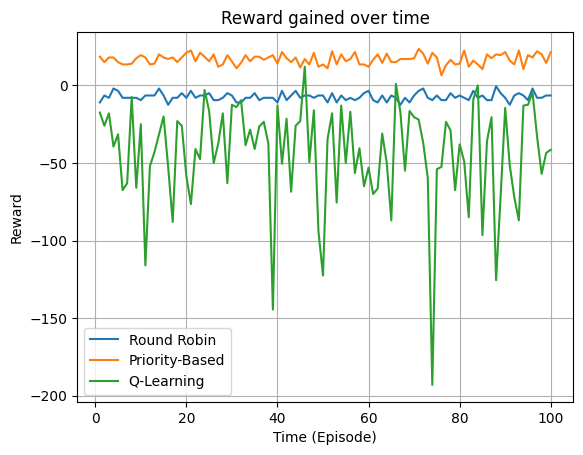

In [11]:
if __name__ == "__main__":
    env = VacuumCleanerEnv(m=5, n=5, obstacle=(2, 2))
    agent = QLearningAgent(env)

    results = {
        "round-robin": run_ep(env, "round-robin", max_steps=1000, num_ep=100),
        "priority-based": run_ep(env, "priority-based", max_steps=1000, num_ep=100),
        "q-learning": run_ep(env, "q-learning", agent=agent, max_steps=1000, num_ep=100)
    }
    save(results, "reward_ep.csv")

    episodes = np.arange(1, 101)
    plt.figure()
    plt.plot(episodes, results["round-robin"], label="Round Robin")
    plt.plot(episodes, results["priority-based"], label="Priority-Based")
    plt.plot(episodes, results["q-learning"], label="Q-Learning")
    plt.xlabel("Time (Episode)")
    plt.ylabel("Reward")
    plt.title("Reward gained over time")
    plt.legend()
    plt.grid(True)
    plt.show()

Evaluation and Analysis

## Part 3: Q-learning with Load Balancing Problem

In [ ]:
"""
Load Balancing Environment Simulation

This program simulates a load balancing environment where tasks are distributed among multiple servers. 
Each server has a queue with a limited size, and tasks are processed based on their arrival and the server's availability.

Key Components:
1. Task: Represents a task with a specific processing time.
2. Server: Represents a server that processes tasks. Each server has a queue to hold tasks waiting for processing.
3. LoadBalancingEnv: A custom OpenAI Gym environment that simulates the load balancing scenario. 
     The environment allows agents to decide which server to send a task to, aiming to maximize rewards by minimizing 
     dropped tasks and reducing waiting times.

The goal is to design a load balancing strategy that optimally distributes tasks among servers to maximize efficiency.

Classes:
- Task: Represents a task with a specific processing time.
- Server: Represents a server with a queue of limited size.
- LoadBalancingEnv: Custom Gym environment for the load balancing problem.

Usage:
- The environment can be used to train reinforcement learning agents to learn optimal load balancing strategies.
"""

import random
from collections import deque

class Task:
      """A task with a unique id and required processing time (in time steps)."""

      def __init__(self, task_id: int, processing_time: int):
            self.task_id = task_id  # Unique identifier for tracking
            self.processing_time = processing_time  # Number of steps needed to finish


class Server:
      """
      A server with:
      - one currently running task
      - a waiting queue with finite capacity
      """

      def __init__(self, queue_capacity: int):
            self.queue_capacity = queue_capacity  # Max number of tasks waiting in queue
            self.queue = deque()  # FIFO queue of waiting tasks
            self.current_task = None  # Task being processed right now
            self.remaining_time = 0  # Steps left for current_task

      def run_one_step(self):
            """
            Execute one simulation step on this server.

            Returns:
                  completed_task (Task | None): task completed at this step, if any.
            """
            completed_task = None

            # Process one time unit for currently running task
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE

            # If server becomes idle, immediately pull next task from queue
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE

            return completed_task

      def add_task(self, task: Task) -> bool:
            """
            Try to add a task to this server.

            Rules:
            - If server is idle: start processing immediately.
            - Else if queue has room: enqueue task.
            - Else: reject (drop) task.

            Returns:
                  bool: True if accepted, False if dropped.
            """
            # Start immediately if server is free
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE

            # Otherwise enqueue if capacity allows
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE

            # Queue full -> task dropped
            return False

      def queue_length(self) -> int:
            # Current number of waiting tasks (excluding running task)
            return len(self.queue)

In [ ]:
class LoadBalancingEnv(gym.Env):
      """
      Custom Gym environment for load balancing.

      Action:
            Choose a server index to receive the new incoming task.

      State:
            - each server's remaining processing time and queue length
            - global time step

      Metrics tracked:
            - total_created_tasks
            - accepted_tasks
            - dropped_tasks
            - completed_tasks
            - drop_rate
      """

      metadata = {"render.modes": ["human"]}

      def __init__(self, n_servers: int = 3, queue_capacity: int = 2, seed: int = None):
            super().__init__()
            self.n_servers = n_servers
            self.queue_capacity = queue_capacity
            self.rng = random.Random(seed)  # Local random generator for reproducibility

            # Create server pool
            self.servers = [Server(queue_capacity) for _ in range(n_servers)]
            self.time = 0  # Global simulation step
            self.total_reward = 0.0  # Accumulated reward over episode

            # Task tracking
            self.next_task_id = 0
            self.tasks_created = {}     # task_id -> Task
            self.tasks_completed = set()  # IDs of completed tasks
            self.tasks_dropped = set()  # IDs of dropped tasks
            self.tasks_accepted = set()  # IDs of accepted tasks

            # RL spaces
            # Define action space with n_servers 
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            self.action_space = 

            # Define observation space as a dict containing server states and global time
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            self.observation_space = 


      def _new_task(self) -> Task:
            """Create one new incoming task with random processing time [1, 5]."""
            # Create a new task with a unique ID and random processing time between 1 and 5
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            t = 
            self.tasks_created[t.task_id] = t
            self.next_task_id += 1
            return t

      def reset(self, *, seed=None, options=None):
            """Reset environment state and all tracking metrics."""
            # Optional reseed to make episode deterministic from this point
            if seed is not None:
                  self.rng.seed(seed)

            # Reinitialize server states, time, and rewards
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE

            # Clear all task statistics
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE


            # Gymnasium-style reset return: (observation, info)
            return self._get_observation(), {}

      def step(self, action: int):
            """
            Run one simulation step:
            1) Advance all servers by one time step.
            2) Generate one new task.
            3) Route task to selected server.
            4) Compute reward and return transition tuple.
            """
            reward = 0.0

            # 1) Process running tasks on each server
            # For each server, call run_one_step() to advance processing. If a task completes, add to completed set and give a positive reward (+2.0)
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE


            # 2) Generate one new incoming task
            new_task = self._new_task()

            # 3) Route task based on action (selected server index)
            # Try to add the new task to the selected server. 
            # If accepted, add to accepted set and give a small reward (+0.5). 
            # If dropped, add to dropped set and give a strong penalty (-5.0).
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            
      
            # 4) Add congestion penalty proportional to queue sizes
            # To encourage the agent to balance load and avoid long queues, subtract a small penalty (e.g., -0.5) for each task waiting in any server's queue.
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            

            # Update global counters
            self.total_reward += reward
            self.time += 1

            # This environment currently never ends by itself
            terminated = False
            truncated = False
            info = self._get_info()

            return self._get_observation(), reward, terminated, truncated, info

      def _get_observation(self):
            """Build observation dict from current system state."""
            # As a hint to design your observation, we provide the following structure:
            return {
                  "servers": tuple(
                         {
                               "remaining_time": float(server.remaining_time),
                               "queue_length": server.queue_length(),
                         }
                         for server in self.servers
                  ),
                  "time": float(self.time),
            }

      def _get_info(self):
            """Return useful metrics for logging/evaluation."""
            # Compute metrics based on requirements on your lab assignment. Here are some examples:
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            total_created = 
            dropped = 
            completed = 
            accepted = 

            # Safe division to avoid divide-by-zero at the beginning
            # Calculate some key performance metrics
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            drop_rate = 
            #...

            return {
                  # Some example info fields: time, dropped tasks, dop_rate, etc.
            }

In [ ]:
def load_balancing_policy(option="random", env=None):
      """Simple baseline policy."""
      if option == "random":
            # Uniform random server selection
            return env.action_space.sample()
      # Define other policies based on the option string
      ### YOU NEED TO WRITE YOUR CODE BELOW ###
      # HERE      
         
      raise ValueError(f"Unsupported policy option: {option}")

In [ ]:
if __name__ == "__main__":
      # Create environment and reset initial state
      env = LoadBalancingEnv(n_servers=3, queue_capacity=2, seed=42)
      obs, info = env.reset()

      # Run fixed number of simulation steps with random policy
      for step in range(20): # 20 episodes = 20 steps = 20 seconds of simulated time = 20 tasks created
            action = load_balancing_policy(option="random", env=env)
            obs, reward, terminated, truncated, info = env.step(action)
            
            # Print every value you want to track at each step
            # Save metrics to a csv file for later analysis
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE

      # Print summary statistics after simulation ends.
      ### YOU NEED TO WRITE YOUR CODE BELOW ###
      # HERE

In [ ]:
def save_metrics(...):
     # Placeholder for a function to save metrics
     pass

Evaluation and Analysis

## CONGRATULATIONS TEAM!

Congratulations to the team for completing Lab02 - Introduction to Q-learning.
Keep up the effort in the next sections.

References: https://gymnasium.farama.org/ 

## ADDITIONAL INFORMATION

**Author**: M.Sc. Phan Trung Phat - Department of Computer Networks and Communications, UIT

**Contact**: phatpt@uit.edu.vn
